<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_Cultural_Capital_AI_Literacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# [CELL 1 - Dependencies & NLP Framework Setup]
!pip install -q sentence-transformers scikit-learn pandas matplotlib seaborn

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import classification_report, confusion_matrix

print("Initializing Semantic Qualitative Codebook Analysis Probe...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Execution Device: {device}")

Initializing Semantic Qualitative Codebook Analysis Probe...
Execution Device: cuda


In [7]:
# [CELL 2 - Community Cultural Wealth Codebook Definition]

YOSSO_CULTURAL_CAPITAL_CODEBOOK = {
    "resistant": {
        "definition": "Knowledge and skills fostered through oppositional behavior that challenges systemic inequities, algorithmic bias, unfair automated grading, and privacy surveillance.",
        "anchors": [
            "We need to audit and challenge biased facial recognition cameras in our neighborhood.",
            "Automated grading systems are unfair to non-native speakers and should be protested.",
            "Students should have the right to opt out of privacy monitoring software."
        ]
    },
    "aspirational": {
        "definition": "The ability to maintain hopes and dreams for the future even in the face of real or perceived barriers in technology access.",
        "anchors": [
            "I want to become an AI engineer so I can build tools that help my community thrive.",
            "Despite our school lacking advanced CS labs, I am learning to code models on my phone.",
            "I dream of creating technology that solves healthcare disparities in underfunded clinics."
        ]
    },
    "linguistic": {
        "definition": "Intellectual and social skills attained through communication experiences in more than one language, dialect, or storytelling tradition.",
        "anchors": [
            "Our bilingual translating skills help us prompt generative models in both Spanish and English.",
            "Translating AI technical jargon into local community slang makes it accessible for everyone.",
            "Using native storytelling structures helps craft better prompts for generative LLMs."
        ]
    },
    "familial": {
        "definition": "Cultural knowledge nurtured among family members that carries a sense of community history, memory, and cultural intuition.",
        "anchors": [
            "My grandmother taught me oral history traditions that I am using to train a community archive chatbot.",
            "Family wisdom helps us decide which local data should remain private and sacred.",
            "Learning technology together with my siblings helps keep our household connected."
        ]
    },
    "social": {
        "definition": "Networks of people and community resources that provide emotional and instrumental support to navigate societal institutions.",
        "anchors": [
            "We organized a neighborhood youth club to share free AI learning resources and tools.",
            "Connecting with local community mentors helped us learn how to audit algorithmic bias.",
            "Working together in study circles helps us solve complex computer science problems."
        ]
    },
    "navigational": {
        "definition": "Skills of maneuvering through social institutions and unsupportive environments not designed for underrepresented groups.",
        "anchors": [
            "We found workarounds to access AI tools when our school blocked educational websites.",
            "Navigating complex grant funding allowed our local library to acquire computer hardware.",
            "Learning how to self-advocate enabled us to request advanced robotics courses."
        ]
    },
    "communal": {
        "definition": "Collective orientation emphasizing mutual care, resource sharing, and community well-being over individual achievement.",
        "anchors": [
            "We are designing an AI tool specifically to help local food banks distribute supplies efficiently.",
            "Sharing AI literacy skills with neighborhood elders ensures no one gets left behind.",
            "Our focus is using technology to protect local small businesses from economic distress."
        ]
    },
    "creative": {
        "definition": "Imaginative, artistic, and expressive practices used to re-interpret, appropriate, or reshape digital technologies.",
        "anchors": [
            "Using generative image models to mix traditional indigenous patterns with futuristic digital murals.",
            "Blending local hip-hop lyricism with prompt engineering to create interactive digital poetry.",
            "Reshaping standard web design to reflect our community's visual heritage and colors."
        ]
    }
}

print(f"Loaded {len(YOSSO_CULTURAL_CAPITAL_CODEBOOK)} Capital Dimensions into the Qualitative Codebook.")

Loaded 8 Capital Dimensions into the Qualitative Codebook.


In [8]:
# [CELL 3 - Semantic Embedding Qualitative Classifier Engine]

class SemanticCapitalClassifier:
    """
    Qualitative text analysis engine using SentenceTransformers to map student dialogue
    utterances to Community Cultural Wealth dimensions via semantic cosine similarity.
    """
    def __init__(self, codebook: Dict[str, Dict[str, Any]], model_name: str = "all-MiniLM-L6-v2"):
        self.codebook = codebook
        self.model = SentenceTransformer(model_name)
        self.category_names = list(codebook.keys())

        # Build category reference embeddings by averaging anchor definitions
        self.category_embeddings = {}
        for cat, data in codebook.items():
            corpus = [data["definition"]] + data["anchors"]
            embeddings = self.model.encode(corpus, convert_to_tensor=True)
            # Mean pooling across definition + anchor vectors
            self.category_embeddings[cat] = torch.mean(embeddings, dim=0, keepdim=True)

    def classify_utterance(self, text: str) -> Dict[str, Any]:
        text_embedding = self.model.encode(text, convert_to_tensor=True)

        similarities = {}
        for cat, cat_emb in self.category_embeddings.items():
            sim = util.cos_sim(text_embedding, cat_emb).item()
            similarities[cat] = sim

        predicted_category = max(similarities, key=similarities.get)

        return {
            "text": text,
            "predicted_category": predicted_category,
            "confidence_score": similarities[predicted_category],
            "similarity_scores": similarities
        }

classifier = SemanticCapitalClassifier(YOSSO_CULTURAL_CAPITAL_CODEBOOK)

# Sanity Check Demonstration
demo_query = "Our school uses an automated attendance tracker that flags students unfairly, so we want to protest it."
res = classifier.classify_utterance(demo_query)
print(f"Demo Query: '{res['text']}'")
print(f"Predicted Category: {res['predicted_category'].upper()} (Cosine Similarity: {res['confidence_score']:.4f})")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Demo Query: 'Our school uses an automated attendance tracker that flags students unfairly, so we want to protest it.'
Predicted Category: RESISTANT (Cosine Similarity: 0.4720)


In [9]:
# [CELL 4 - Independent Out-of-Sample Evaluation Dataset]

OUT_OF_SAMPLE_STUDENT_DIALOGUE = [
    # Resistant Capital
    {"text": "The surveillance software installed on our school laptops invades our privacy, so we wrote a guide to disable it.", "ground_truth": "resistant", "module": "Algorithmic Surveillance"},
    {"text": "Automated essay scoring systems penalize students who use African American Vernacular English.", "ground_truth": "resistant", "module": "School AI Analytics"},

    # Aspirational Capital
    {"text": "Even though nobody in my family went to college, I am determined to study machine learning at university.", "ground_truth": "aspirational", "module": "AI Career Pathways"},
    {"text": "I believe that mastering generative tools will help me launch a tech business in my hometown.", "ground_truth": "aspirational", "module": "AI Career Pathways"},

    # Linguistic Capital
    {"text": "Switching between Spanish and English helps us craft richer prompts for creative writing models.", "ground_truth": "linguistic", "module": "Generative Storytelling"},
    {"text": "We translate complex algorithmic terms into everyday dialect so our community can understand how models work.", "ground_truth": "linguistic", "module": "AI Literacy Basics"},

    # Familial Capital
    {"text": "My uncle taught me how local farms manage irrigation, which inspired my dataset design for climate AI.", "ground_truth": "familial", "module": "Community Data Systems"},
    {"text": "Preserving stories from our family elders is our main motivation for building a spoken-word archivist bot.", "ground_truth": "familial", "module": "Generative Storytelling"},

    # Social Capital
    {"text": "We formed a student council tech committee to share coding tutorials across all grade levels.", "ground_truth": "social", "module": "Community AI Hubs"},
    {"text": "Our community center connected us with local university researchers who donated GPU time for our project.", "ground_truth": "social", "module": "Community AI Hubs"},

    # Navigational Capital
    {"text": "When the school firewall blocked developer APIs, we figured out how to run quantized open-source models locally.", "ground_truth": "navigational", "module": "School AI Analytics"},
    {"text": "We successfully applied for municipal youth micro-grants to fund our neighborhood robotics workshop.", "ground_truth": "navigational", "module": "Community AI Hubs"},

    # Communal Capital
    {"text": "Instead of selling our app, we made it open-source so local food pantries can coordinate donations.", "ground_truth": "communal", "module": "Community Data Systems"},
    {"text": "Our goal is building a public heat-map tool to help senior citizens stay safe during heatwaves.", "ground_truth": "communal", "module": "Community Data Systems"},

    # Creative Capital
    {"text": "We trained an image model on traditional textile art to print modern cultural banners for the neighborhood center.", "ground_truth": "creative", "module": "Generative Storytelling"},
    {"text": "I combined local street art styles with neural style transfer to customize our public library website.", "ground_truth": "creative", "module": "Generative Storytelling"}
]

benchmark_df = pd.DataFrame(OUT_OF_SAMPLE_STUDENT_DIALOGUE)
print(f"Loaded {len(benchmark_df)} out-of-sample student dialogue utterances across {benchmark_df['module'].nunique()} workshop modules.")

Loaded 16 out-of-sample student dialogue utterances across 7 workshop modules.


In [11]:
# [CELL 5 - Quantitative Metric Evaluation Harness]
from typing import Tuple, Dict, Any

def evaluate_semantic_classifier(df: pd.DataFrame, classifier_engine: SemanticCapitalClassifier) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    predictions = []
    confidence_scores = []

    for _, row in df.iterrows():
        out = classifier_engine.classify_utterance(row["text"])
        predictions.append(out["predicted_category"])
        confidence_scores.append(out["confidence_score"])

    df["predicted_category"] = predictions
    df["confidence_score"] = confidence_scores
    df["is_correct"] = (df["ground_truth"] == df["predicted_category"])

    categories = classifier_engine.category_names
    report = classification_report(
        df["ground_truth"],
        df["predicted_category"],
        labels=categories,
        zero_division=0,
        output_dict=True
    )

    return df, report

results_df, perf_report = evaluate_semantic_classifier(benchmark_df, classifier)

print("============================================================")
print("OUT-OF-SAMPLE QUALITATIVE CLASSIFIER EVALUATION REPORT")
print("============================================================")
metrics_table = pd.DataFrame(perf_report).transpose()
print(metrics_table.to_string())
print("============================================================")
print(f"Overall Accuracy: {perf_report['accuracy']*100:.1f}%")
print(f"Macro F1-Score: {perf_report['macro avg']['f1-score']:.4f}")
print("============================================================")

OUT-OF-SAMPLE QUALITATIVE CLASSIFIER EVALUATION REPORT
              precision  recall  f1-score  support
resistant      1.000000   1.000  1.000000    2.000
aspirational   1.000000   1.000  1.000000    2.000
linguistic     1.000000   0.500  0.666667    2.000
familial       1.000000   0.500  0.666667    2.000
social         0.666667   1.000  0.800000    2.000
navigational   1.000000   1.000  1.000000    2.000
communal       0.666667   1.000  0.800000    2.000
creative       1.000000   1.000  1.000000    2.000
accuracy       0.875000   0.875  0.875000    0.875
macro avg      0.916667   0.875  0.866667   16.000
weighted avg   0.916667   0.875  0.866667   16.000
Overall Accuracy: 87.5%
Macro F1-Score: 0.8667


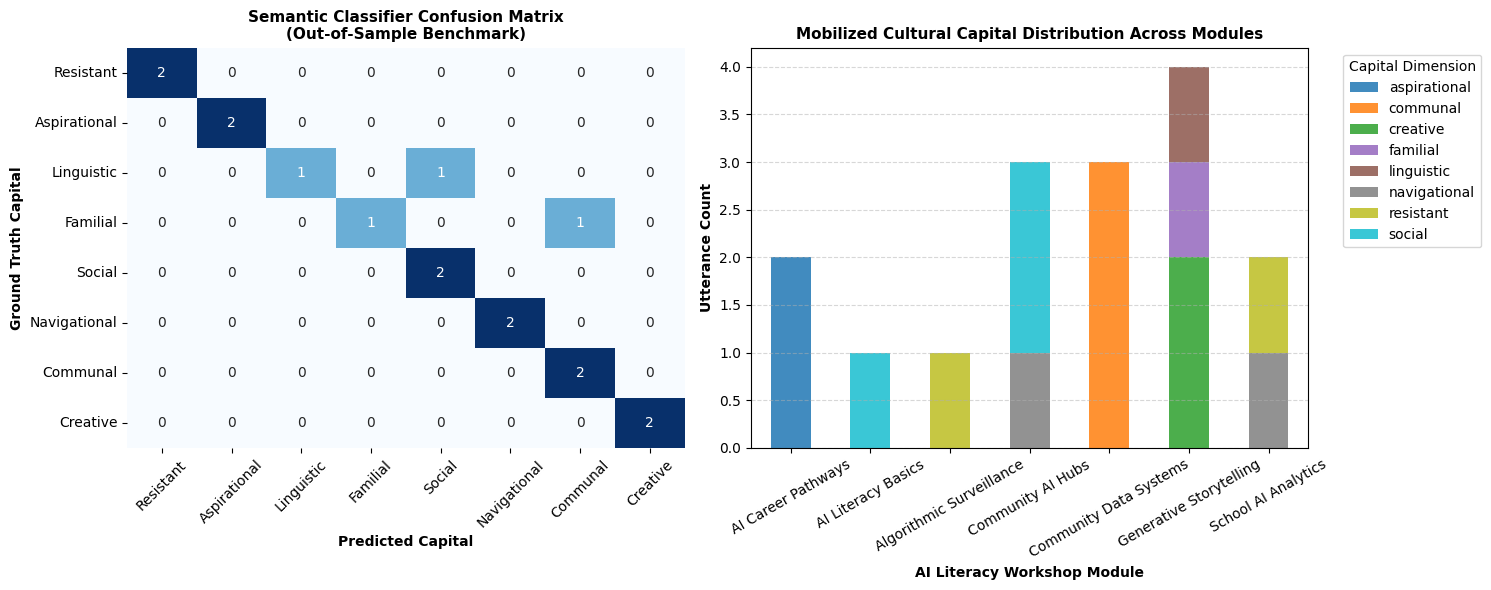

In [12]:
# [CELL 6 - Publication-Grade Visualization Dashboard]

def plot_semantic_evaluation_dashboard(df: pd.DataFrame, categories: List[str]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Confusion Matrix Heatmap
    cm = confusion_matrix(df["ground_truth"], df["predicted_category"], labels=categories)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[c.title() for c in categories], yticklabels=[c.title() for c in categories], ax=ax1, cbar=False)
    ax1.set_title("Semantic Classifier Confusion Matrix\n(Out-of-Sample Benchmark)", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Predicted Capital", fontsize=10, fontweight='bold')
    ax1.set_ylabel("Ground Truth Capital", fontsize=10, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)

    # 2. Capital Distribution Across Workshop Modules
    module_capital = pd.crosstab(df["module"], df["predicted_category"])
    module_capital.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10', alpha=0.85)
    ax2.set_title("Mobilized Cultural Capital Distribution Across Modules", fontsize=11, fontweight='bold')
    ax2.set_xlabel("AI Literacy Workshop Module", fontsize=10, fontweight='bold')
    ax2.set_ylabel("Utterance Count", fontsize=10, fontweight='bold')
    ax2.legend(title="Capital Dimension", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_semantic_evaluation_dashboard(results_df, classifier.category_names)